## Import istotnych bibliotek

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
from itertools import cycle
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.decomposition import PCA
from collections import defaultdict
from sklearn.preprocessing import label_binarize
from sklearn.preprocessing import StandardScaler
from sklearn.multiclass import OneVsRestClassifier
from sklearn import svm
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import scale
from scipy import stats
import warnings
warnings.filterwarnings("ignore")

## Podział danych na treningowe i testowe

In [2]:
df = pd.read_csv('./datasets/ToxInsBaseClass.csv')
print(df.shape)
dftrain, dftest = train_test_split(df, test_size=0.3, random_state=42)


dftrain.head()

(137, 23)


,Latitude,Longitude,MaximumDepth,SecchiDepth,Sampling Depth,T_Surf,T_Epi,Zeu / Zmix,BuoyFreq,TP,...,MC_dmRR,MC_RR,MC_dmLR,MC_LR,CYN,ATX,ToxinRichness,TDI,TTC,Toxicity
60,54.391722,24.366056,7.0,0.95,6.0,20.8,19.8,0.49,0.00,0.03,...,5.181,0.072,0.269,0.035,0.298,0.034,7,0.61,6.009,3
122,59.508320,18.044800,5.0,0.59,4.0,18.9,18.8,0.39,0.00,0.08,...,0.000,0.212,0.017,0.098,0.002,0.000,4,0.82,0.329,2
93,53.575556,21.548889,24.0,0.80,10.0,23.3,19.1,0.15,0.01,0.08,...,2.449,0.000,1.330,0.037,0.057,0.000,5,1.14,5.280,3
44,39.778733,-5.605400,80.0,1.10,14.0,25.1,24.3,0.04,0.00,0.03,...,0.000,0.114,0.012,0.320,0.001,0.283,6,1.14,0.737,2
15,48.777950,16.742849,5.5,0.32,3.0,22.1,21.4,1.28,0.00,0.33,...,0.000,0.000,0.015,0.000,0.000,0.006,2,0.58,0.021,1


In [3]:
dftrain.info()

<class 'pandas.core.frame.DataFrame'>
Index: 95 entries, 60 to 102
Data columns (total 23 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Latitude         95 non-null     float64
 1   Longitude        95 non-null     float64
 2   MaximumDepth     95 non-null     float64
 3   SecchiDepth      95 non-null     float64
 4   Sampling Depth   95 non-null     float64
 5   T_Surf           95 non-null     float64
 6   T_Epi            95 non-null     float64
 7   Zeu / Zmix       95 non-null     float64
 8   BuoyFreq         95 non-null     float64
 9   TP               95 non-null     float64
 10  TN               95 non-null     float64
 11  Chlorophyl_a     95 non-null     float64
 12  MC_YR            95 non-null     float64
 13  MC_dmRR          95 non-null     float64
 14  MC_RR            95 non-null     float64
 15  MC_dmLR          95 non-null     float64
 16  MC_LR            95 non-null     float64
 17  CYN              95 n

# Heatmapa

<Axes: >

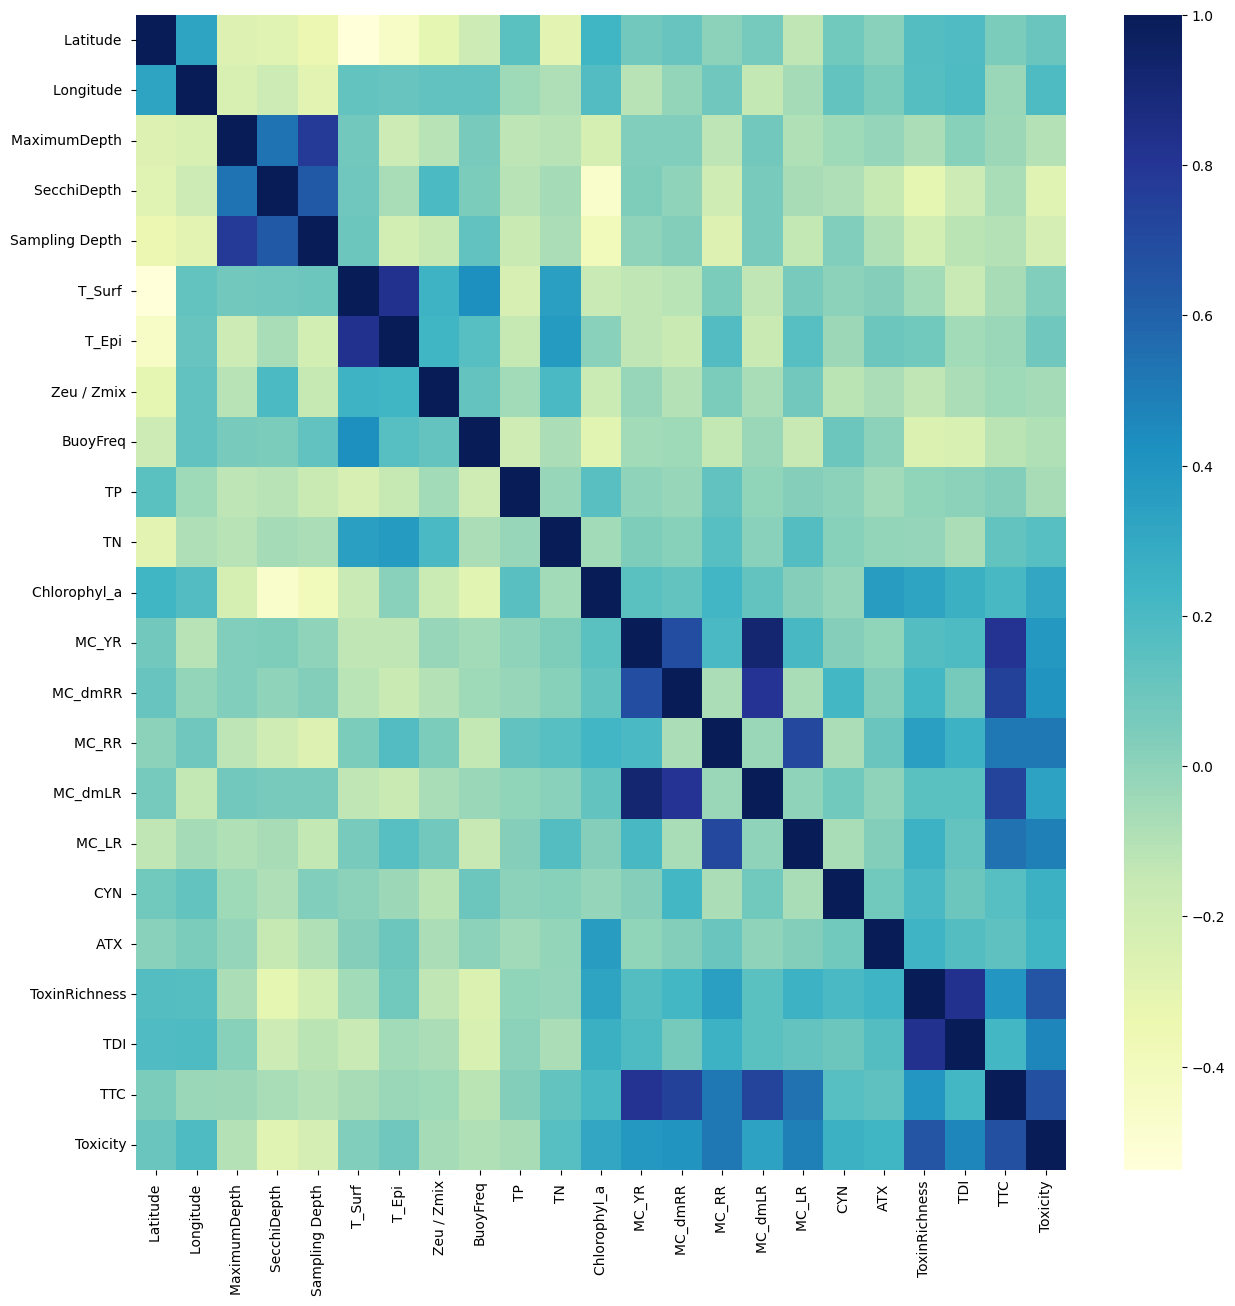

In [4]:
plt.figure(figsize=(15, 15))
sns.heatmap(dftrain.corr(), fmt=".2f", cmap="YlGnBu")

# Opis wszystkich kolumn w zbiorze danych

In [5]:
dftrain.describe()

,Latitude,Longitude,MaximumDepth,SecchiDepth,Sampling Depth,T_Surf,T_Epi,Zeu / Zmix,BuoyFreq,TP,...,MC_dmRR,MC_RR,MC_dmLR,MC_LR,CYN,ATX,ToxinRichness,TDI,TTC,Toxicity
count,95.000000,95.000000,95.000000,95.000000,95.000000,95.000000,95.000000,95.000000,95.000000,95.000000,...,95.000000,95.000000,95.000000,95.000000,95.000000,95.000000,95.000000,95.000000,95.000000,95.000000
mean,51.465065,15.102293,18.546316,1.547368,6.308421,21.666316,20.331579,0.945789,0.004842,0.075263,...,0.283116,0.214116,0.084105,0.241295,0.032853,0.031621,3.863158,0.749263,0.973284,1.789474
std,6.094934,10.595891,31.827323,1.253842,4.758188,3.128782,3.031861,1.144017,0.006501,0.081173,...,1.000096,0.537629,0.330852,0.665763,0.137543,0.145345,1.679732,0.413118,1.929898,0.784080
min,37.842800,-25.788917,1.200000,0.230000,0.700000,9.000000,8.700000,0.040000,0.000000,0.010000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.001000,1.000000
25%,47.936329,11.033888,4.200000,0.695000,3.000000,19.600000,18.800000,0.385000,0.000000,0.030000,...,0.000000,0.000000,0.002000,0.000000,0.000000,0.000000,2.000000,0.445000,0.029500,1.000000
50%,52.441171,16.796722,8.000000,1.200000,5.000000,21.300000,19.700000,0.550000,0.000000,0.050000,...,0.000000,0.017000,0.006000,0.021000,0.000000,0.000000,4.000000,0.840000,0.182000,2.000000
75%,55.690958,21.952447,19.000000,1.850000,8.500000,23.300000,21.750000,1.035000,0.010000,0.085000,...,0.060500,0.125000,0.044500,0.099000,0.001000,0.003000,5.000000,1.065000,0.791000,2.000000
max,62.239189,32.832500,251.000000,6.200000,30.000000,30.000000,28.900000,8.800000,0.030000,0.610000,...,6.590000,3.309000,2.895000,3.968000,1.158000,1.333000,7.000000,1.440000,12.184000,3.000000


In [6]:
dftrain.columns

Index(['Latitude ', 'Longitude ', 'MaximumDepth ', 'SecchiDepth ',
       'Sampling Depth ', 'T_Surf ', 'T_Epi ', 'Zeu / Zmix', 'BuoyFreq', 'TP ',
       'TN ', 'Chlorophyl_a ', 'MC_YR ', 'MC_dmRR ', 'MC_RR ', 'MC_dmLR ',
       'MC_LR ', 'CYN ', 'ATX ', 'ToxinRichness', 'TDI', 'TTC', 'Toxicity'],
      dtype='object')

# Wizualizacja rozkładów cech względem poziomu toksyczności

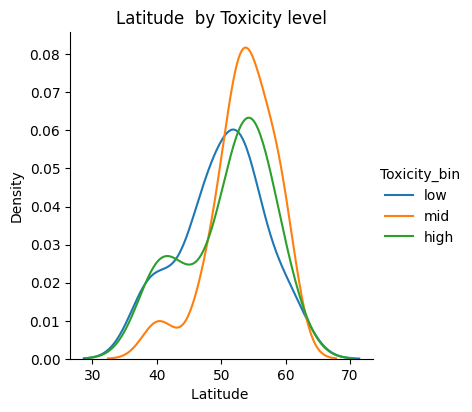

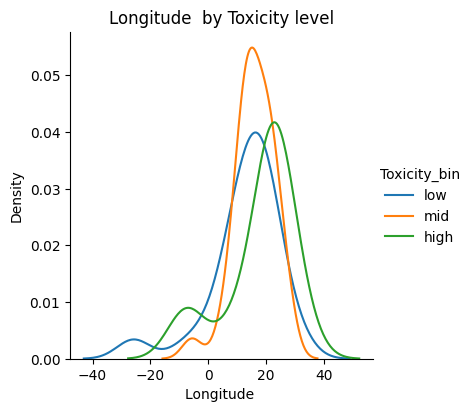

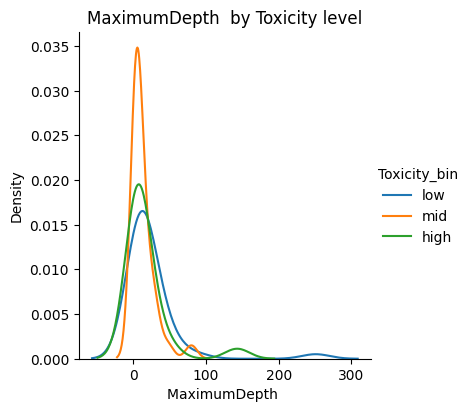

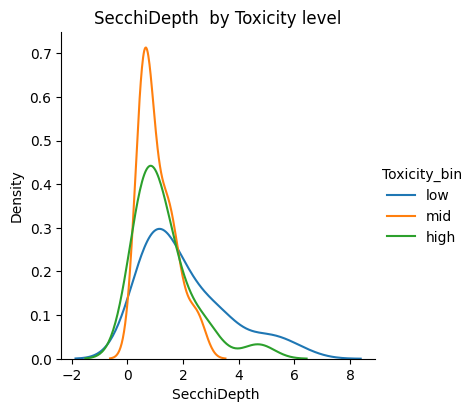

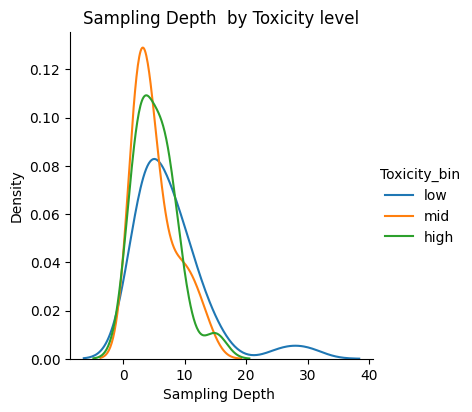

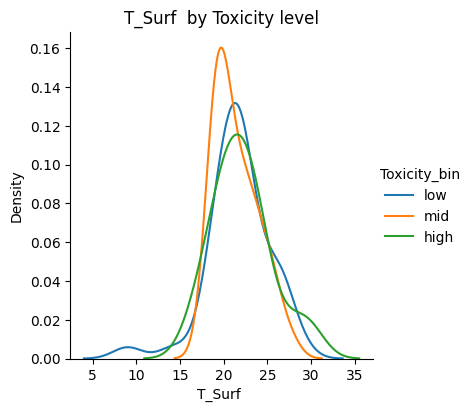

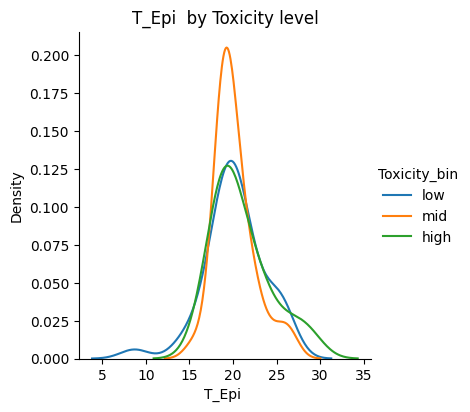

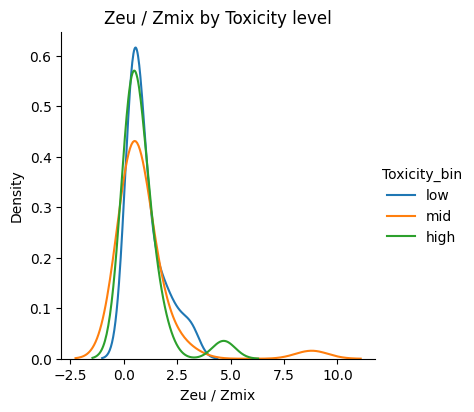

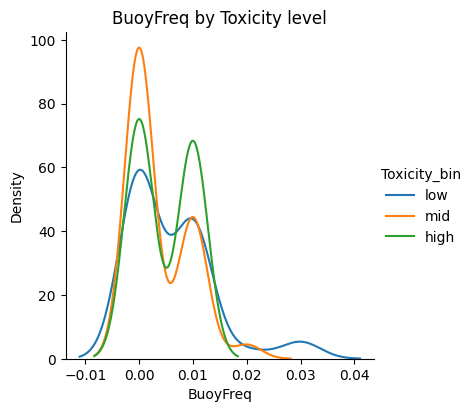

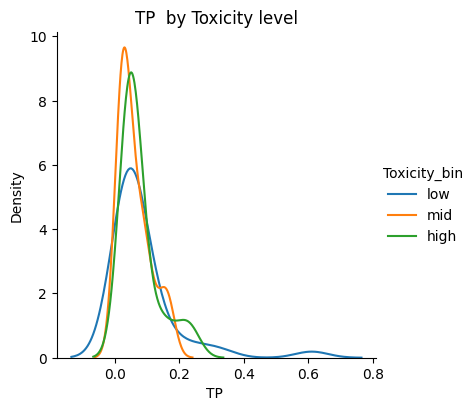

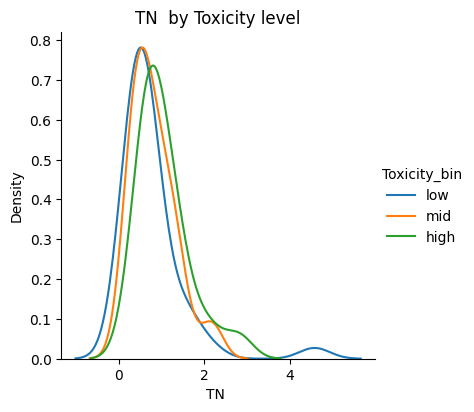

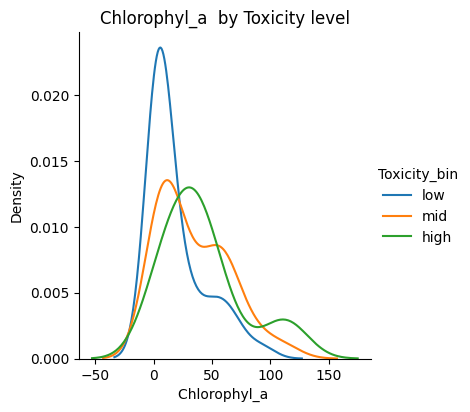

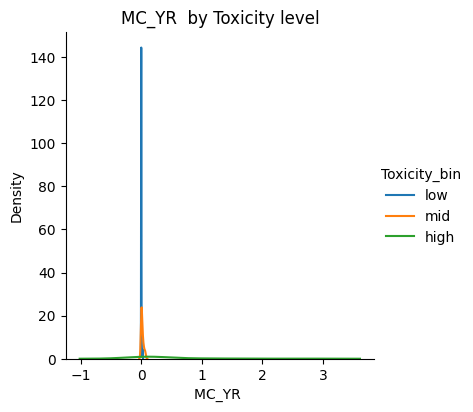

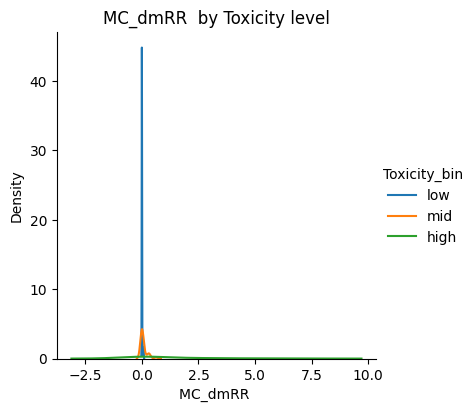

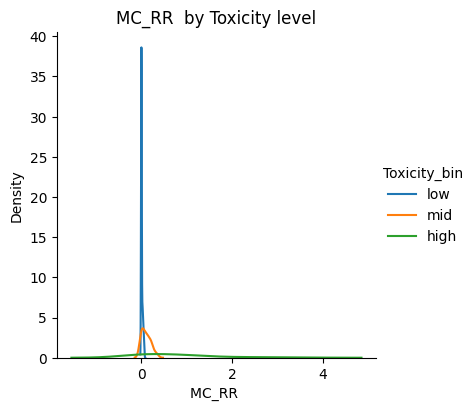

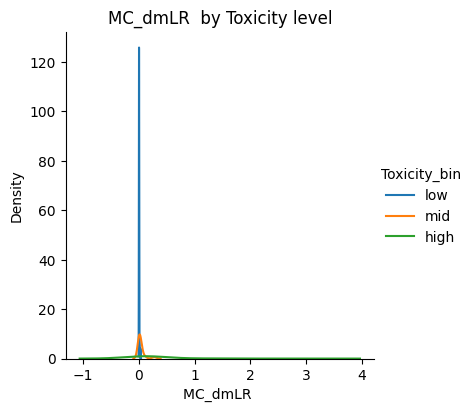

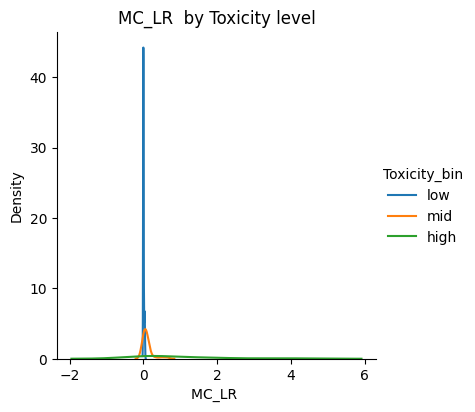

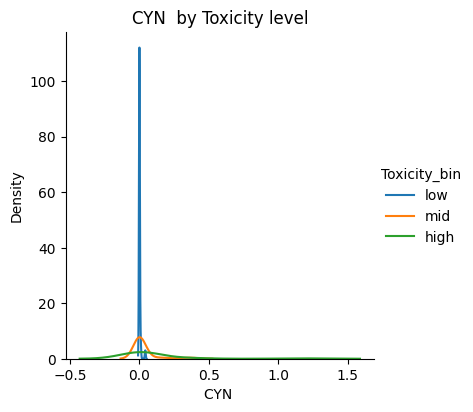

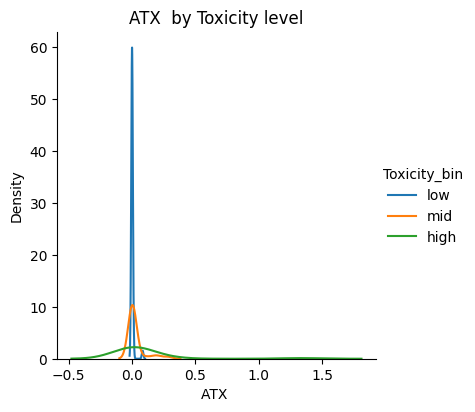

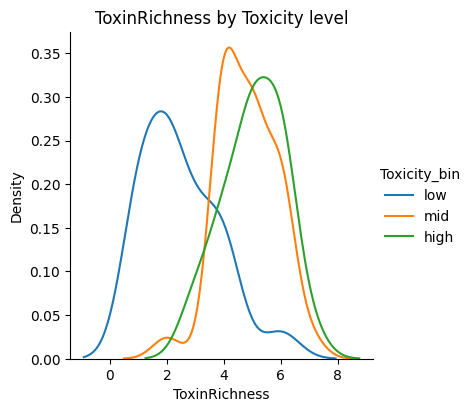

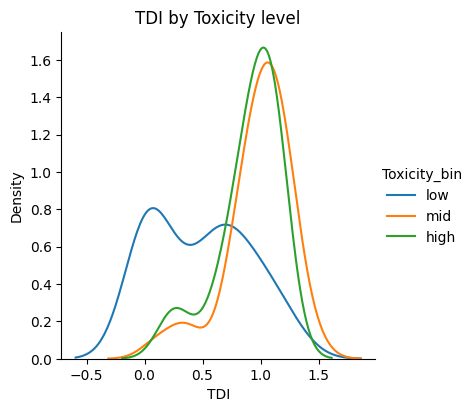

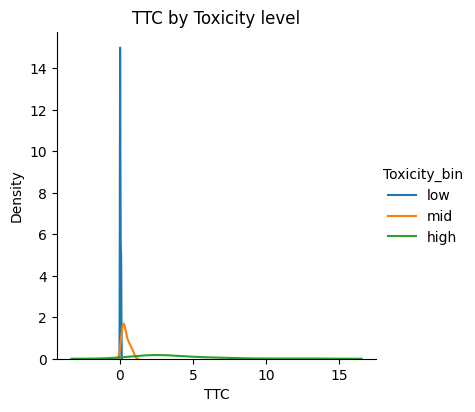

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Tworzymy kategorie jako odpowiednik Cover_Type
dftrain["Toxicity_bin"] = pd.cut(
    dftrain["Toxicity"],
    bins=3,
    labels=["low", "mid", "high"]
)


# Lista kolumn do rysowania (bez Toxicity i bez kategorii)
cols = [c for c in dftrain.columns if c not in ["Toxicity", "Toxicity_bin"]]

# Pętla jak w Twoim przykładzie
for col in cols:
    g = sns.FacetGrid(dftrain, hue="Toxicity_bin", height=4)
    g.map(sns.kdeplot, col)
    g.add_legend()
    plt.title(f"{col} by Toxicity level")
    plt.show()


# Selekcja cech testem Chi-Kwadrat

In [12]:
import scipy.stats as stats
from scipy.stats import chi2_contingency
import pandas as pd

class ChiSquare:
    def __init__(self, dataframe):
        self.df = dataframe
        self.p = None #P-Value
        self.chi2 = None #Chi Test Statistic
        self.dof = None

        self.dfObserved = None
        self.dfExpected = None

    def _print_chisquare_result(self, colX, alpha):
        result = ""
        if self.p < alpha:
            result="{0} is IMPORTANT for Prediction".format(colX)
        else:
            result="{0} is NOT an important predictor. (Discard {0} from model)".format(colX)

        print(result)

    def TestIndependence(self, colX, colY, alpha=0.05):
        X = self.df[colX].astype(str)
        Y = self.df[colY].astype(str)
        self.dfObserved = pd.crosstab(Y,X)
        chi2, p, dof, expected = stats.chi2_contingency(self.dfObserved.values)
        self.p = p
        self.chi2 = chi2
        self.dof = dof

        self.dfExpected = pd.DataFrame(expected, columns=self.dfObserved.columns, index=self.dfObserved.index)

        self._print_chisquare_result(colX, alpha)

#Initialize ChiSquare Class
cT = ChiSquare(dftrain)

#Feature Selection
testColumns = ['Latitude ', 'Longitude ', 'MaximumDepth ', 'SecchiDepth ',
       'Sampling Depth ', 'T_Surf ', 'T_Epi ', 'Zeu / Zmix', 'BuoyFreq', 'TP ',
       'TN ', 'Chlorophyl_a ', 'MC_YR ', 'MC_dmRR ', 'MC_RR ', 'MC_dmLR ',
       'MC_LR ', 'CYN ', 'ATX ', 'ToxinRichness', 'TDI', 'TTC', 'Toxicity']

for var in testColumns:
    cT.TestIndependence(colX=var, colY="Toxicity")

Latitude  is NOT an important predictor. (Discard Latitude  from model)
Longitude  is NOT an important predictor. (Discard Longitude  from model)
MaximumDepth  is NOT an important predictor. (Discard MaximumDepth  from model)
SecchiDepth  is NOT an important predictor. (Discard SecchiDepth  from model)
Sampling Depth  is NOT an important predictor. (Discard Sampling Depth  from model)
T_Surf  is NOT an important predictor. (Discard T_Surf  from model)
T_Epi  is NOT an important predictor. (Discard T_Epi  from model)
Zeu / Zmix is NOT an important predictor. (Discard Zeu / Zmix from model)
BuoyFreq is NOT an important predictor. (Discard BuoyFreq from model)
TP  is NOT an important predictor. (Discard TP  from model)
TN  is NOT an important predictor. (Discard TN  from model)
Chlorophyl_a  is NOT an important predictor. (Discard Chlorophyl_a  from model)
MC_YR  is IMPORTANT for Prediction
MC_dmRR  is IMPORTANT for Prediction
MC_RR  is NOT an important predictor. (Discard MC_RR  from mod

# Ważne kategorie dla predykcji
-MC_YR  
-MC_dmRR  
-MC_dmLR  
-MC_LR  
-ToxinRichness 
-Toxicity 

# Sprawdzenie czy kolumny wartości odstające i zduplikowane wartości odstające

In [15]:
import itertools
import numpy as np
import pandas as pd

# Wybieramy tylko kolumny numeryczne
num_cols = dftrain.select_dtypes(include=np.number).columns

# Wykrywanie outlierów
outlier_list = []

for col in num_cols:
    q1 = np.percentile(dftrain[col], 25)
    q3 = np.percentile(dftrain[col], 75)
    step = 1.5 * (q3 - q1)
    
    # Wiersze, które są outlierami
    outliers_rows = dftrain.loc[~((dftrain[col] >= q1 - step) & (dftrain[col] <= q3 + step)), :]
    
    print(f"Data points considered outliers for the feature '{col}':")
    print(outliers_rows.index.tolist())
    
    outlier_list.append(list(outliers_rows.index))

# 3. Łączenie wszystkich indeksów outlierów
all_outliers = list(itertools.hain.from_iterable(outlier_list))
uniq_outlier = list(set(all_outliers))

# 4. Wybranie tylko tych indeksy, które pojawiają się więcej niż raz
dup_outliers = [i for i in uniq_outlier if all_outliers.count(i) > 1]

# 5. Filtracja tylko indeksy istniejące w dftrain
dup_outliers_valid = [i for i in dup_outliers if i in dftrain.index]

# 6. Tworzenie nowego DataFrame bez outlierów
real_data = dftrain.drop(index=dup_outliers_valid).reset_index(drop=True)

# 7. Informacje o wynikach
print("Outliers list:\n", uniq_outlier)
print("Length of outliers list:", len(uniq_outlier))

print("Duplicate outliers (to remove):\n", dup_outliers_valid)
print("Length of duplicates list:", len(dup_outliers_valid))

print("Shape of cleaned DataFrame:", real_data.shape)


Data points considered outliers for the feature 'Latitude ':
[]
Data points considered outliers for the feature 'Longitude ':
[44, 39, 53, 113, 38, 116, 136]
Data points considered outliers for the feature 'MaximumDepth ':
[44, 39, 9, 5, 49, 7, 3, 54, 126]
Data points considered outliers for the feature 'SecchiDepth ':
[9, 49, 54, 91, 118, 52]
Data points considered outliers for the feature 'Sampling Depth ':
[49, 54]
Data points considered outliers for the feature 'T_Surf ':
[135, 111]
Data points considered outliers for the feature 'T_Epi ':
[65, 53, 135, 95, 111, 41]
Data points considered outliers for the feature 'Zeu / Zmix':
[86, 119, 13, 129, 50, 96, 134, 41]
Data points considered outliers for the feature 'BuoyFreq':
[97, 134]
Data points considered outliers for the feature 'TP ':
[15, 73, 68, 70, 72, 79, 111, 74]
Data points considered outliers for the feature 'TN ':
[65, 43, 79, 41, 107, 87]
Data points considered outliers for the feature 'Chlorophyl_a ':
[79]
Data points con